In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
df = pd.read_excel("Online Retail.xlsx")

In [4]:
# To get a brief idea about the columns that the data has , and what it refers to.
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# To get the total number of rows and columns present in the data.
df.shape

(541909, 8)

In [6]:
#To check that how many null values are there in the columns that are present in the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# To give the total number of count that how many null values are there.
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
(df.isnull().sum() / len(df)) * 100
# So this step is used to check that which column if the dataset has what percentage of null values present in them.

# Condition for data cleaning
# < 1% → usually safe to ignore or drop rows
# 5–20% → needs careful handling
# > 20–30% → serious issue; dropping or imputing changes data meaning


# So for this step we conclude that CustomerID has 24.9(~25%) of null values and about  0.26% is present in Description.

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [9]:
# So dropping the  entire column permanently will cause a lot of issues , so we will temporarily drop them and then store the dataset in a new dataframe.

df_Clean_CustID = df.dropna(subset=['CustomerID'])

In [10]:
df_Clean_CustID

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [11]:
x = (df_Clean_CustID['Quantity'] < 0).sum()
print(x)

# This is step is used to check the products returned/ Corrections
# Quantity < 0 - Means Product Returned
# Quantity = 0 - Data Correction



8905


In [12]:
y = (df_Clean_CustID['UnitPrice'] < 0).sum()
print(y)

0


In [13]:
z = df_Clean_CustID['InvoiceNo'].astype(str).str.startswith('C').sum()
print(z)

# We check this because for a complete transaction to happen the product should not be returned , or else the invoice gets cancelled and it is not considered a transaction.

8905


In [14]:
df_clean = df_Clean_CustID[~df_Clean_CustID['InvoiceNo'].astype(str).str.startswith('C')]

# It removes all rows where the InvoiceNo starts with 'C' (i.e., cancelled transactions)

In [15]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [16]:
df_Clean_CustID['Total_Price'] = df_Clean_CustID['Quantity'] * df_Clean_CustID['UnitPrice']

# To get the total price of all the items , by multiplying the quantity ordered and the unit price of it.

# On the later stages we can diffferentiate which country , has the most orders and which generates the most and the least revenue.

/tmp/ipykernel_1091/924215033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Clean_CustID['Total_Price'] = df_Clean_CustID['Quantity'] * df_Clean_CustID['UnitPrice']


In [17]:
reference_date = df_clean['InvoiceDate'].max()

df.groupby('CustomerID')

#It creates a reference point (latest date in dataset) which is used to calculate recency.

In [18]:
# Grouping data on the basis  of the Invoice number and TotalPrice on the basis of CustomerID

df_Clean_CustID = df_Clean_CustID.rename(columns={'Total_Price': 'TotalPrice'})

df_Clean_CustID.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

,InvoiceNo,TotalPrice
CustomerID,,
12346.0,2,0.00
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40
...,...,...
18280.0,1,180.60
18281.0,1,80.82
18282.0,3,176.60


In [19]:
print(df_Clean_CustID.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']


In [20]:
# It finds the latest date and takes it as the reference date , to find the last purchasing day of any customer , or any other info relevant to it.
reference_date = df_Clean_CustID['InvoiceDate'].max()

customer_df = df_Clean_CustID.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [21]:
customer_df[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,91.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,0.000000,1.000000,-4287.630000
25%,16.000000,1.000000,293.362500
50%,49.000000,3.000000,648.075000
75%,142.000000,5.000000,1611.725000
max,373.000000,248.000000,279489.020000


In [22]:
# Renames columns to clean, meaningful names
customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [23]:
customer_df[['Recency','Frequency','Monetary']].describe()

# This step helps us to understand the basic Statistical Structure of the data.

# min - Gives the minimum value
# max - gives the maximum value
# std - Gives the spread of the data
# mean - Gives the average
# (25,50,75) Percentile - How many values are below are particular value


,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,91.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,0.000000,1.000000,-4287.630000
25%,16.000000,1.000000,293.362500
50%,49.000000,3.000000,648.075000
75%,142.000000,5.000000,1611.725000
max,373.000000,248.000000,279489.020000


In [24]:
# Skewness tells you how asymmetric your data is. It also tells you that how stretched your data is on one side

# Monetary - It has the highest skewness.


customer_df[['Recency','Frequency','Monetary']].skew()

# Monetary highly skewwed because of the large amount of purchases that is made by the small number of customers.

,0
Recency,1.249665
Frequency,11.412274
Monetary,21.705287


3 Cases of Skewness

Balanced - Equal on both sides , Mean and Median are almost equivalent , and skewness is almost zero.

Right Skewed - Tail goes to the right , Mean > Median , there are very few large values , Most data is small.

Left Skewed - Tail goes to the left , Median > Mean , there are very few small values , Most data is large.
**bold text**



<Axes: >

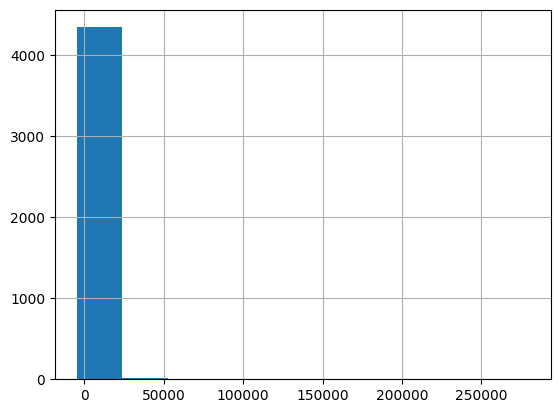

In [25]:
customer_df['Monetary'].hist()

<Axes: >

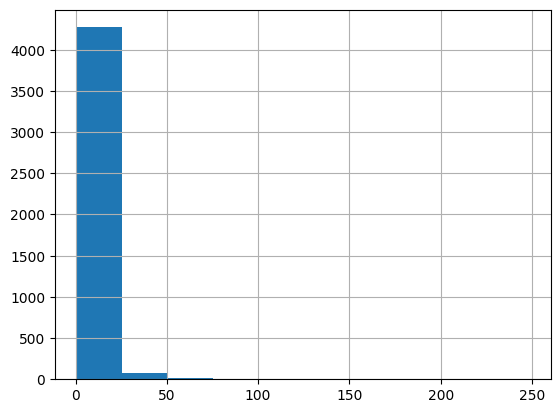

In [26]:
customer_df['Frequency'].hist()

<Axes: >

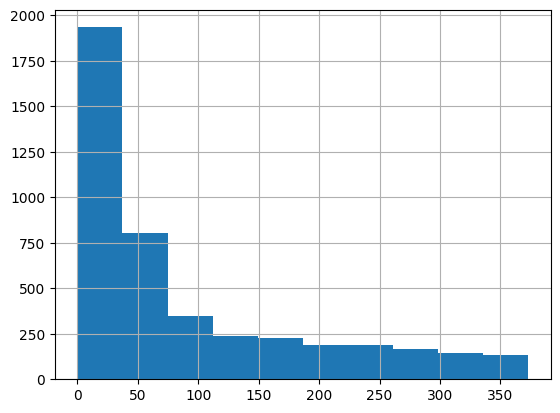

In [27]:
customer_df['Recency'].hist()

In [28]:
# Next Step is Performing Bivariate Analysis :

# Bivariate Analysis helps us to understand that how two variables are moving together .

# Steps Involved in Bivariate Analysis

# Step_1: Select the variables
# Step_2: Measure the numerical relationship between the variables
# Step_3: Vizualise the relationship
# Step_4: Interpret the pattern
# Step_5: Draw Insight

# In a nutshell if , Bivariate Analysis to summarised then :  Select pair → measure → visualize → interpret → conclude


In [29]:
customer_df[['Recency', 'Frequency', 'Monetary']].corr()

# Recency and Frequency are negatively related , meaning that customers who haven't purchase recently buy less .
# Monetary and Frequency are positively related , meaning that customers who purchase frequently tend to spend less.
# Recency and Monetary are negativvely related , meaning that customers who haven't purchased recently tend spend less.

,Recency,Frequency,Monetary
Recency,1.000000,-0.259342,-0.132001
Frequency,-0.259342,1.000000,0.566122
Monetary,-0.132001,0.566122,1.000000


So the customers who buy frequently and contribute to the business to generate higher revenue should be priotised.

In [30]:
country_revenue = df_Clean_CustID.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

In [31]:
country_revenue.head(5)

,TotalPrice
Country,
United Kingdom,6767873.394
Netherlands,284661.540
EIRE,250285.220
Germany,221698.210
France,196712.840


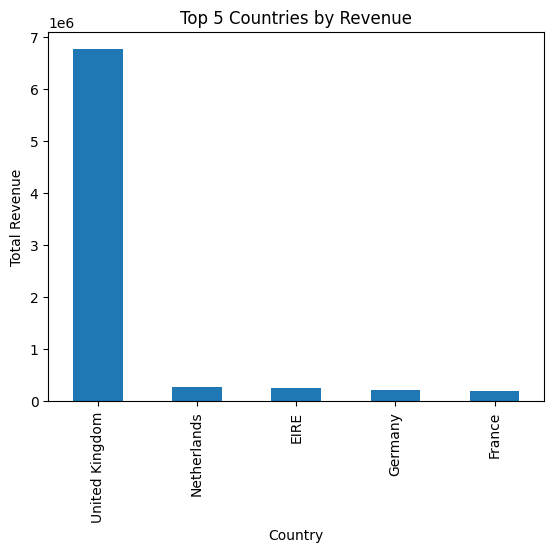

In [32]:
country_revenue.head(5).plot(kind='bar')
plt.title('Top 5 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.show()

In [33]:
customers_per_country = df_Clean_CustID.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)


In [34]:
customers_per_country.head(5)

,CustomerID
Country,
United Kingdom,3950
Germany,95
France,87
Spain,31
Belgium,25


In [35]:
avg_spend = country_revenue / customers_per_country

avg_spend.sort_values(ascending=False).head()

,0
Country,
EIRE,83428.406667
Netherlands,31629.060000
Australia,15230.807778
Singapore,9120.390000
Sweden,4574.488750


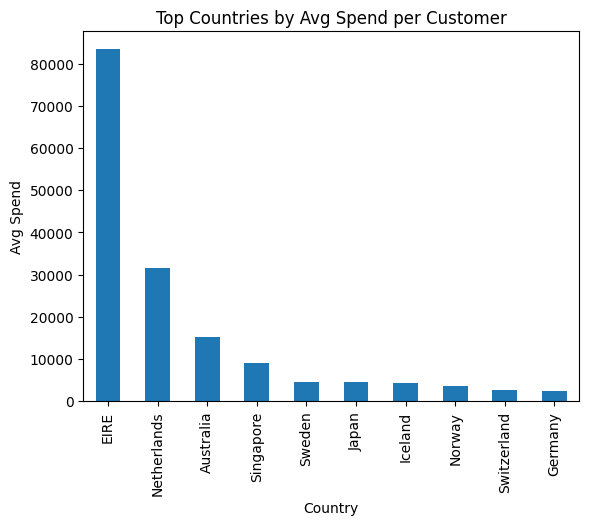

In [36]:
avg_spend.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Countries by Avg Spend per Customer')
plt.ylabel('Avg Spend')
plt.show()

**The UK generates the highest total revenue due to a large number of customers, but the average spend per customer is lower compared to countries like EIRE and the Netherlands, where fewer customers contribute higher individual spending.**


In [37]:
# This is the Clustering part.

In [38]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
RFM_scaled = SS.fit_transform(customer_df[['Recency','Frequency','Monetary']])

In [39]:
RFM_scaled.shape

(4372, 3)

In [43]:
# Importing KMeans to perform clustering , so now we will decide the number of clusters . (n)
from sklearn.cluster import KMeans
KM = KMeans(n_clusters=3, random_state=42)
clusters = KM.fit_predict(RFM_scaled)


In [44]:
customer_df['Cluster'] = clusters

customer_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Cluster 0 : Recency is Moderate , Frequency is Moderate , Monetary is also Moderate , they are all the regular customers.
# Cluster 1 : Recency is Very High(Inactive from a long time) , Frequency is also Low , Monetary is also Very Low.
# Cluster 2 : Recency is Very Low(Recently Purchased) , Frequency is High , Monetary is also very High.

,Recency,Frequency,Monetary
Cluster,,,
0,39.091245,5.595561,1821.839757
1,245.365611,1.846154,459.541105
2,5.086957,86.869565,81835.857391


**Through this project, it was concluded that businesses can significantly improve customer retention and revenue generation by segmenting customers based on Recency, Frequency, and Monetary (RFM) behavior.

RFM-based segmentation helps businesses identify high-value customers, prioritize personalized strategies for customer retention, and focus on low-value or inactive customers to improve engagement and convert them into profitable customers over time.

The analysis also highlighted that customer behavior varies significantly across segments, making customer-centric decision-making more effective than applying a generalized marketing strategy.**